# Anomaly Detection on mlg-ulb Credit Card Fraud Data

## 1. Problem Framing

Anomaly detection is the identification of data points that do not align with expected values. By detecting such inconsistencies in a data set, valuable insights can be drawn. In the context of this project, these anomalies can help identify fraudulent credit card transactions.

In unsupervised learning, patterns and structure are inferred directly from the data without the use of labeled outcomes. In contrast, supervised learning relies on predefined labels and aims to learn a mapping between input features and those labels.

Although the dataset we are using includes a `class` feature that indicates if the transaction is legitimate (0) or fraudulent (1), this project is framed as an unsupervised anomaly detection problem. The explored detection methods are designed to identify anomalies without relying on labelled data during training.


This approach better represents real-world fraud detection scenarios, where fraudulent activities are evolving and not fully labeled in advance. Thus, the `class` labels will be used in the evaluation, not the training of our unsupervised methods. Therefore, this problem is explicitly treated as an unsupervised anomaly detection task.

## 2. Detection Methods

### Preprocessing

The `Class` label was removed from training to maintain an unsupervised learning framework, but retained for evaluation. The `Time` feature was removed as it represents a relative timestamp with limited standalone predictive value. Features were standardized using z-score normalization to ensure consistent scaling across dimensions.

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def get_dataset(filename="archive/creditcard.csv"):
    df = pd.read_csv(filename)

    # Identify any missing values:
    values = df.isnull().sum()
    print(values[values > 0])

    # Unsupervised, so drop Class in X
    df_dropped = df.drop(columns=['Class', 'Time'])
    y = df['Class']

    # These samples are already time-ordered, so we simply split them such that
    # train = transactions in the past, test = transactions in the future
    split_idx = int(len(df) * 0.8)
    X_train = df_dropped.iloc[:split_idx]
    X_test = df_dropped.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    # Normalize the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

### Statistical Method: Moving Average

In [30]:
import numpy as np
import pandas as pd

def moving_average_detector(
    X_train,
    X_test,
    y_test,
    window_size=50,
    quantile=0.99
):
    # Create DataFrames
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    #########
    # TRAIN #
    #########

    train_mean = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    train_std = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    train_z = (X_train_df - train_mean) / train_std
    train_scores = np.sqrt((train_z ** 2).sum(axis=1))

    # Threshold from train only
    threshold = train_scores.quantile(quantile)

    ########
    # TEST #
    ########

    # Give the test set the recent past from training
    X_combined = pd.concat(
        [X_train_df.iloc[-(window_size - 1):], X_test_df],
        ignore_index=True
    )

    test_mean = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    test_std = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    test_z = (X_combined - test_mean) / test_std
    test_scores_all = np.sqrt((test_z ** 2).sum(axis=1))

    # Drop the train scores, keep test scores. The higher the score, the more
    # likely the sample is an anomaly.
    test_scores = test_scores_all.iloc[window_size - 1:].reset_index(drop=True)

    # Binary predictions
    y_pred = (test_scores > threshold).astype(int)

    # Replace the current index with 0, 1, 2, etc
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

X_train, X_test, y_train, y_test = get_dataset()

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=100000,
    quantile=0.9
)

Series([], dtype: int64)


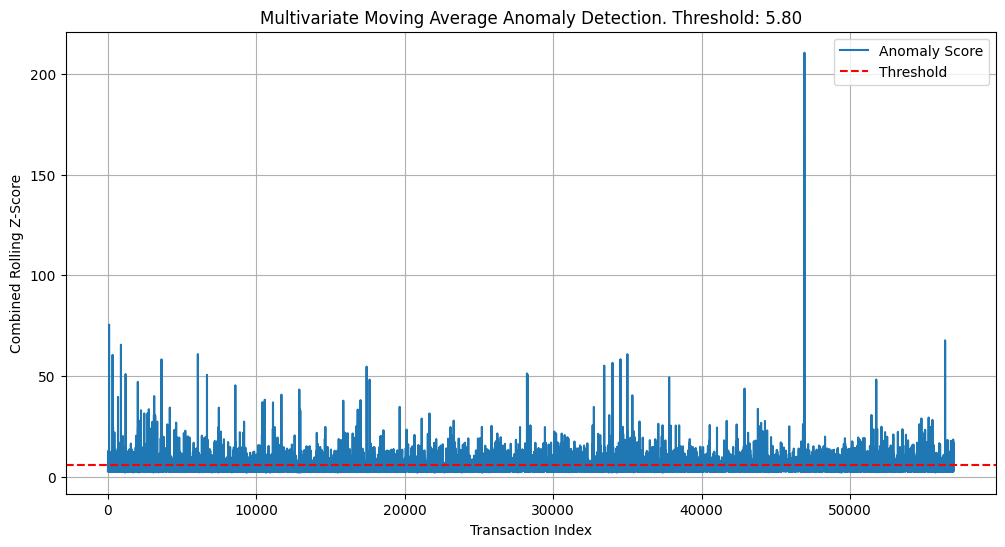

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ma_output['scores'], label='Anomaly Score')
plt.axhline(y=ma_output['threshold'], color='r', linestyle='--', label='Threshold')
plt.xlabel('Transaction Index')
plt.ylabel('Combined Rolling Z-Score')
plt.title(f"Multivariate Moving Average Anomaly Detection. Threshold: {ma_output['threshold']:.2f}")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = ma_output["y_true"]
y_pred = ma_output["y_pred"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

Precision: 0.92%
Recall:    89.33%
F1 Score:  1.82%


### Distance-based Method: kNN Anomaly Detection

This implements k-Nearest Neighbors (kNN) as a distance-based anomaly detection method, where the anomaly score is defined as the distance to the k-th nearest neighbor. Since anomalies are expected to lie in low-density regions, they require a larger radius to reach k neighbors, resulting in higher scores. We use Euclidean distance because the features are already standardized, making distances meaningful across dimensions. The anomaly threshold is set using a quantile of the training scores, ensuring it is based only on normal behavior and can be tuned to control the precision–recall tradeoff.

In [8]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# A KNN built for unsupervised anomaly detection using largest scoring (Kth nearest neighbor)
def knn_anomaly_detection(
    X_train,
    X_test,
    y_test,
    k=5,
    quantile=0.99
):
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    # Assume data is already scaled in preprocessing
    X_train_scaled = X_train_df
    X_test_scaled = X_test_df

    # Added optimization with n_jobs
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train_scaled)

    distances, _ = knn.kneighbors(X_test_scaled)

    # Distance to k-th nearest training neighbor
    test_scores = pd.Series(distances[:, -1])

    # Threshold from train scores only
    train_distances, _ = knn.kneighbors(X_train_scaled)
    train_scores = pd.Series(train_distances[:, -1])
    threshold = train_scores.quantile(quantile)

    y_pred = (test_scores > threshold).astype(int)

    # realign index
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

### ML Method: Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

def isolation_forest_detector(
        X_train,
        X_test,
        y_test,
        contamination=0.01
):

    #########
    # TRAIN #
    #########

    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)

    ########
    # TEST #
    ########

    # More positive = more likely to be fraudulent
    scores = -model.decision_function(X_test)

    y_pred = model.predict(X_test)
    y_pred = (y_pred == -1).astype(int)

    y_true = y_test.reset_index(drop=True)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": scores
    }

X_train, X_test, y_train, y_test = get_dataset()

if_output = isolation_forest_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    contamination=0.01
)


Series([], dtype: int64)


## 3. Threshold Optimization

In [5]:
#!pip install mlflow

import mlflow

# setup mlflow experiment
mlflow.set_experiment("Credit Card Fraud - Anomaly Detection")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1777002793619, experiment_id='1', last_update_time=1777002793619, lifecycle_stage='active', name='Credit Card Fraud - Anomaly Detection', tags={}, trace_location=None, workspace='default'>

### 3.1 Moving Average Threshold Optimization

#### 3.1.1 Window Tuning

In [31]:
def tune_moving_average_window(
    X_train,
    X_test,
    y_test,
    window_sizes,
    quantile=0.99
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through window sizes to evaluate performance
    for window_size in window_sizes:

        # MLFlow logging
        with mlflow.start_run(run_name=f"MovingAverage_w{window_size}_q{quantile}"):

            # Run moving average
            output = moving_average_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                window_size=window_size,
                quantile=quantile
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Moving Average")
            mlflow.log_param("stage", "window_tuning")
            mlflow.log_param("window_size", window_size)
            mlflow.log_param("quantile", quantile)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "window_size": window_size,
                "quantile": quantile,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,window_size,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,50,0.99,13.443325,0.074941,0.426667,0.127490,0.006944,56492,395,43,32,427
1,100,0.99,14.736443,0.070588,0.400000,0.120000,0.006944,56492,395,45,30,425
2,500,0.99,15.910252,0.070686,0.453333,0.122302,0.007858,56440,447,41,34,481
3,1000,0.99,15.941761,0.080679,0.506667,0.139194,0.007612,56454,433,37,38,471
4,5000,0.99,15.768208,0.078775,0.480000,0.135338,0.007401,56466,421,39,36,457


Best window size: 1000


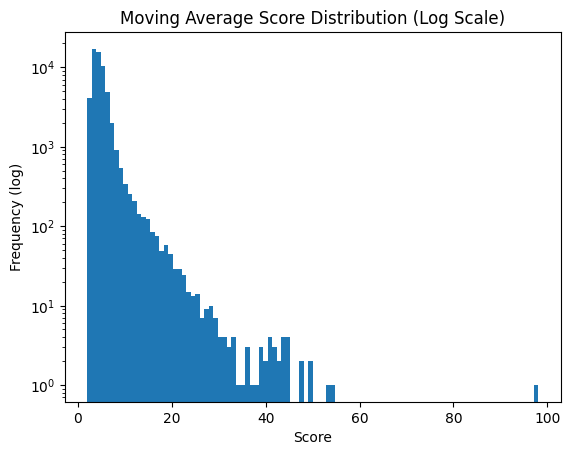

In [35]:
# Run window tuning
window_sizes = [50, 100, 500, 1000, 5000]

X_train, X_test, y_train, y_test = get_dataset()

ma_window_results_df = tune_moving_average_window(
    X_train,
    X_test,
    y_test,
    window_sizes,
    quantile=0.99
)

display(ma_window_results_df)

best_window = int(ma_window_results_df.sort_values(by="f1", ascending=False).iloc[0]["window_size"])
print("Best window size:", best_window)

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=best_window,
    quantile=0.99
)

plt.hist(ma_output["scores"].dropna(), bins=100)
plt.yscale("log")
plt.title("Moving Average Score Distribution (Log Scale)")
plt.xlabel("Score")
plt.ylabel("Frequency (log)")
plt.show()

Smaller window sizes are more sensitive to local fluctuations, resulting in higher recall but increased false positives. Larger window sizes smooth the data more heavily, reducing false positives but also missing some anomalies. A window size of 1000 provides the best trade-off, capturing meaningful deviations while maintaining stability in the anomaly scores.

#### 3.1.2 Threshold Tuning

In [33]:
def tune_moving_average_threshold(
    X_train,
    X_test,
    y_test,
    window_size,
    quantiles
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantiles to evaluate threshold performance
    for q in quantiles:

        # MLFlow logging
        with mlflow.start_run(run_name=f"MovingAverage_w{window_size}_q{q}"):

            # Run moving average
            output = moving_average_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                window_size=window_size,
                quantile=q
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Moving Average")
            mlflow.log_param("stage", "threshold_tuning")
            mlflow.log_param("window_size", window_size)
            mlflow.log_param("quantile", q)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "window_size": window_size,
                "quantile": q,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,window_size,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,1000,0.950,8.087997,0.023180,0.853333,0.045134,0.047410,54190,2697,11,64,2761
1,1000,0.975,10.732168,0.042569,0.760000,0.080622,0.022536,55605,1282,18,57,1339
2,1000,0.990,15.941761,0.080679,0.506667,0.139194,0.007612,56454,433,37,38,471
3,1000,0.995,20.298908,0.053659,0.146667,0.078571,0.003410,56693,194,64,11,205
4,1000,0.999,32.124583,0.000000,0.000000,0.000000,0.000721,56846,41,75,0,41


Best quantile: 0.99
Best threshold: 15.94176139138372


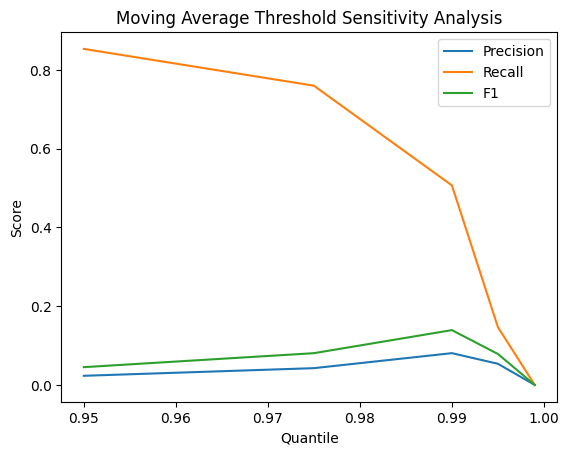

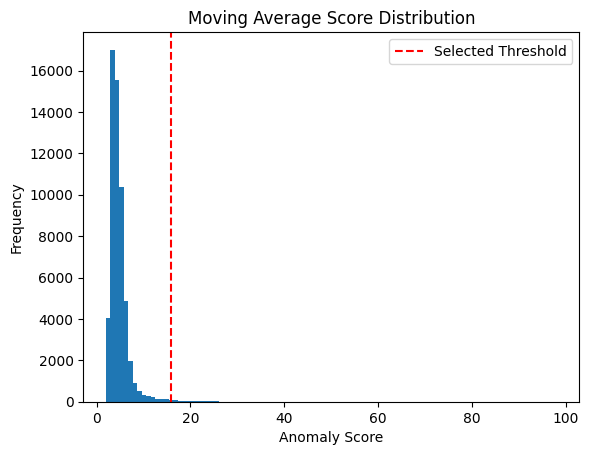

In [36]:
# Run threshold tuning
quantiles = [0.95, 0.975, 0.99, 0.995, 0.999]

X_train, X_test, y_train, y_test = get_dataset()

ma_threshold_results_df = tune_moving_average_threshold(
    X_train,
    X_test,
    y_test,
    window_size=best_window,
    quantiles=quantiles
)

display(ma_threshold_results_df)

# Select best threshold
best_row = ma_threshold_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_ma_quantile = best_row["quantile"]
best_ma_threshold = best_row["threshold"]

print("Best quantile:", best_ma_quantile)
print("Best threshold:", best_ma_threshold)

# Sensitivity plot
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["precision"], label="Precision")
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["recall"], label="Recall")
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("Moving Average Threshold Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution
ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=best_window,
    quantile=best_ma_quantile
)

plt.hist(ma_output["scores"].dropna(), bins=100)
plt.axvline(best_ma_threshold, linestyle="--", label="Selected Threshold", color="r")
plt.title("Moving Average Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The moving average model exhibits a clear sensitivity to threshold selection, with performance varying significantly across quantiles. Lower thresholds (like 0.95) result in high recall by identifying most fraudulent transactions, but introduce a large number of false positives due to the method’s sensitivity to local fluctuations. As the threshold increases, the model becomes more selective, reducing false positives and improving precision, but at the cost of missing fraudulent activity.

The anomaly score distribution is heavily skewed, with the majority of transactions concentrated at low scores and a gradual tail of higher values corresponding to deviations from the rolling statistical baseline. Unlike kNN, where anomalies are defined by spatial isolation, the moving average method captures temporal deviations, resulting in a smoother but less sharply separated tail. The selected threshold at the 0.99 quantile lies near the onset of this tail, capturing significant deviations while avoiding excessive noise from normal variations.

From a performance perspective, this threshold yields the highest F1-score, indicating the best compromise between detecting fraud and limiting false positives. Lower thresholds are overly sensitive, while higher thresholds become too conservative and fail to detect meaningful anomalies.

From a business standpoint, the cost of missing fraudulent transactions outweighs the inconvenience of false positives. However, the moving average method tends to produce more false positives due to its reliance on local statistics, making threshold selection particularly important. The chosen threshold therefore reflects a balance between maintaining acceptable recall and ensuring the system remains operationally feasible

### 3.2 kNN Threshold Optimization

#### 3.2.1 k Tuning

In [9]:
def tune_knn_k(
    X_train,
    X_test,
    y_test,
    k_values,
    quantile=0.99
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through k values to evaluate performance
    for k in k_values:

        # MLFlow logging
        with mlflow.start_run(run_name=f"kNN_k{k}_q{quantile}"):

            # Run kNN
            output = knn_anomaly_detection(
                X_train,
                X_test,
                y_test,
                k=k,
                quantile=quantile
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "kNN")
            mlflow.log_param("stage", "k_tuning")
            mlflow.log_param("k", k)
            mlflow.log_param("quantile", quantile)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)

            results.append({
                "k": k,
                "quantile": quantile,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,k,quantile,threshold,precision,recall,f1,false_positive_rate,false_positives,false_negatives,true_positives
0,3,0.99,5.893125,0.033708,0.800000,0.064690,0.034452,344,3,12
1,5,0.99,6.563285,0.041522,0.800000,0.078947,0.027742,277,3,12
2,10,0.99,7.947128,0.046392,0.600000,0.086124,0.018528,185,6,9
3,20,0.99,9.477530,0.065789,0.666667,0.119760,0.014221,142,5,10
4,50,0.99,12.077962,0.067961,0.466667,0.118644,0.009614,96,8,7


Best k: 20


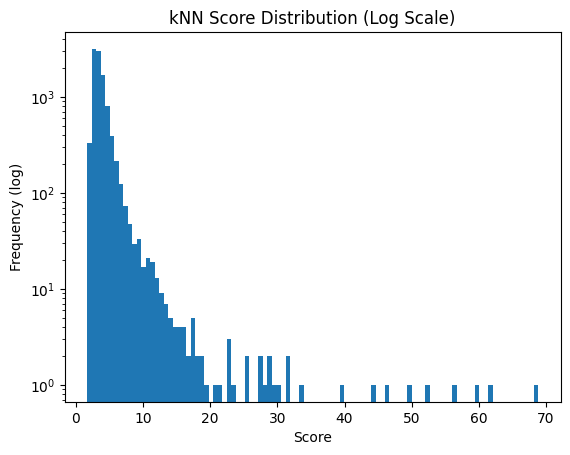

In [27]:
# Run tuning on smaller subset of dataset
X_train, X_test, y_train, y_test = get_dataset()

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

k_values = [3, 5, 10, 20, 50]

k_results_df = tune_knn_k(
    X_train_small,
    X_test_small,
    y_test_small,
    k_values,
    quantile=0.99
)

# Display the results comparing each k value
display(k_results_df)

best_k = int(k_results_df.sort_values(by="f1", ascending=False).iloc[0]["k"])
print("Best k:", best_k)

output = knn_anomaly_detection(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantile=0.99
)

# Plot the score distribution
plt.hist(output["scores"], bins=100)
plt.yscale("log")
plt.title("kNN Score Distribution (Log Scale)")
plt.xlabel("Score")
plt.ylabel("Frequency (log)")
plt.show()

We selected k=20 because it produced the highest F1-score during tuning, balancing recall with a lower false positive rate. Lower k values detected more fraud but produced many more false positives, while larger k values reduced false positives but missed more fraud. Low precision is expected, as only around 0.17% of dataset is fraud, so any false positives at all greatly lower the precision score due to class imbalance.

#### 3.2.2 KNN Threshold Optimization

In [18]:
def tune_knn_threshold(
    X_train,
    X_test,
    y_test,
    k,
    quantiles
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantiles to evaluate threshold performance
    for q in quantiles:

        # MLFlow logging
        with mlflow.start_run(run_name=f"kNN_k{k}_q{q}"):

            # Run kNN
            output = knn_anomaly_detection(
                X_train,
                X_test,
                y_test,
                k=k,
                quantile=q
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "kNN")
            mlflow.log_param("stage", "threshold_tuning")
            mlflow.log_param("k", k)
            mlflow.log_param("quantile", q)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            # Additional metrics for better analysis
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "k": k,
                "quantile": q,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

,k,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,20,0.950,5.175620,0.016009,1.000000,0.031513,0.092339,9063,922,0,15,937
1,20,0.975,6.532754,0.034230,0.933333,0.066038,0.039559,9590,395,1,14,409
2,20,0.990,9.477530,0.065789,0.666667,0.119760,0.014221,9843,142,5,10,152
3,20,0.995,12.134438,0.000000,0.000000,0.000000,0.007611,9909,76,15,0,76
4,20,0.999,23.207579,0.000000,0.000000,0.000000,0.002203,9963,22,15,0,22


Best quantile: 0.99
Best threshold: 9.477529599112113


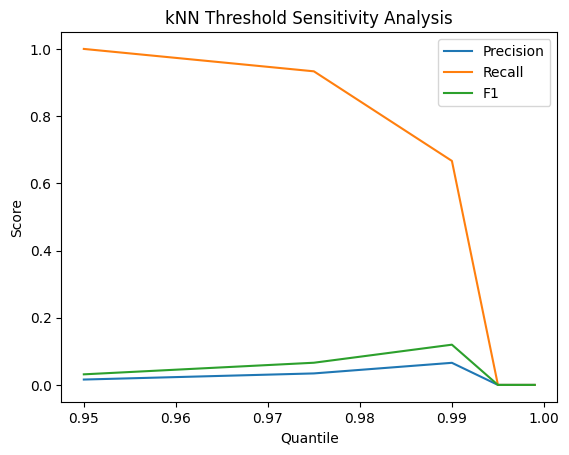

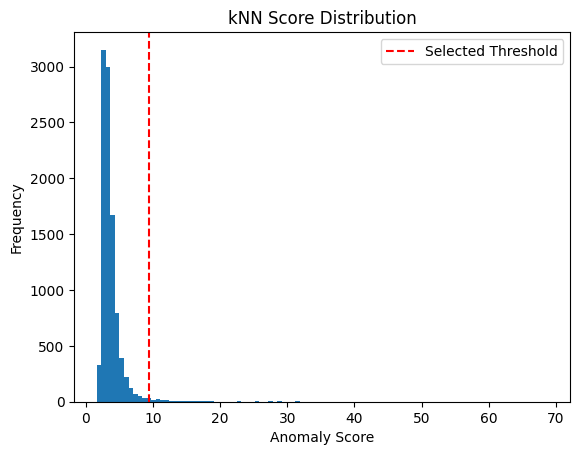

In [26]:
# Run threshold tuning
quantiles = [0.95, 0.975, 0.99, 0.995, 0.999]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

knn_threshold_results_df = tune_knn_threshold(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantiles=quantiles
)

display(knn_threshold_results_df)

# Select best threshold
best_row = knn_threshold_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_quantile = best_row["quantile"]
best_threshold = best_row["threshold"]

print("Best quantile:", best_quantile)
print("Best threshold:", best_threshold)

# Sensitivity plot
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["precision"], label="Precision")
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["recall"], label="Recall")
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("kNN Threshold Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = knn_anomaly_detection(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantile=best_quantile
)

plt.hist(output["scores"], bins=100)
plt.axvline(best_threshold, linestyle="--", label="Selected Threshold", color = 'r')
plt.title("kNN Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The threshold sensitivity analysis reveals a clear trade-off between recall and false positives in the moving average model. Lower thresholds (e.g., 0.95) achieve high recall by detecting most fraudulent transactions but generate many false positives. As the threshold increases, precision improves and the false positive rate decreases, but recall drops sharply. At very high thresholds, the model becomes too conservative and fails to detect fraud.

The anomaly score distribution explains this behavior, as scores are highly skewed with most transactions clustered at low values and a long tail representing abnormal deviations. The selected threshold at the 0.99 quantile lies near the start of this tail, capturing meaningful anomalies while limiting noise from normal variations.

This threshold produces the highest F1-score, indicating the best balance between precision and recall. Lower thresholds are overly sensitive, while higher thresholds are too restrictive, making the selected value a practical compromise based on both the score distribution and performance metrics.

From a business perspective, missing fraudulent transactions is significantly more costly than incorrectly flagging legitimate ones, as undetected fraud can lead to costly things like direct financial loss. However, an excessive number of false positives can overwhelm fraud investigation systems and increase operational costs. The selected threshold balances these by maintaining strong recall to capture a meaningful portion of fraud, while keeping the false positive rate at a manageable level for further review processes.

In [23]:
runs = mlflow.search_runs()
knn_runs = runs[runs["params.method"] == "kNN"]

display(knn_runs[[
    "params.stage",
    "params.k",
    "params.quantile",
    "params.threshold",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.false_positive_rate"
]])

knn_runs.to_csv("knn_mlflow_logs.csv", index=False)

,params.stage,params.k,params.quantile,params.threshold,metrics.precision,metrics.recall,metrics.f1,metrics.false_positive_rate
0,k_tuning,50,0.99,12.077961764124698,0.067961,0.466667,0.118644,0.009614
1,k_tuning,20,0.99,9.477529599112113,0.065789,0.666667,0.119760,0.014221
2,k_tuning,10,0.99,7.947127657007068,0.046392,0.600000,0.086124,0.018528
3,k_tuning,5,0.99,6.563285460290048,0.041522,0.800000,0.078947,0.027742
4,k_tuning,3,0.99,5.893124508102291,0.033708,0.800000,0.064690,0.034452
5,threshold_tuning,20,0.999,23.207578524796848,0.000000,0.000000,0.000000,0.002203
6,threshold_tuning,20,0.995,12.13443816839351,0.000000,0.000000,0.000000,0.007611
7,threshold_tuning,20,0.99,9.477529599112113,0.065789,0.666667,0.119760,0.014221
8,threshold_tuning,20,0.975,6.532754164081307,0.034230,0.933333,0.066038,0.039559
9,threshold_tuning,20,0.95,5.1756196035470445,0.016009,1.000000,0.031513,0.092339


### 3.3 Isolated Forest Optimization

## 4. Evaluation

In [ ]:
X_train, X_test, y_train, y_test = get_dataset()

# Train moving average
ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=1000,
    quantile=0.99
)

# Train kNN
knn_output = knn_anomaly_detection(
    X_train,
    X_test,
    y_test,
    k=20,
    quantile=0.99
)

# Train isolated forest
if_output = isolation_forest_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    contamination=0.01
)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_binary_classifier(y_true, y_pred, scores, plot=True):
    """
    y_true: true labels, 0/1
    y_pred: predicted labels, 0/1
    scores: anomaly/fraud scores, higher = more likely positive
    """

    # Basic metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Curve metrics
    fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)

    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, scores)
    avg_precision = average_precision_score(y_true, scores)

    results = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": false_positive_rate,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "roc_curve": {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": roc_thresholds
        },
        "pr_curve": {
            "precision": pr_precision,
            "recall": pr_recall,
            "thresholds": pr_thresholds
        }
    }

    if plot:
        # Confusion matrix
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        plt.title("Confusion Matrix")
        plt.show()

        # ROC curve
        plt.figure()
        plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate / Recall")
        plt.title("ROC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

        # Precision-recall curve
        plt.figure()
        plt.plot(pr_recall, pr_precision, label=f"AP = {avg_precision:.3f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

    return results

ma_results = evaluate_binary_classifier(
    ma_output['y_true'], 
    ma_output['y_pred'], 
    ma_output['scores']
)

knn_results = evaluate_binary_classifier(
    knn_output['y_true'], 
    knn_output['y_pred'], 
    knn_output['scores']
)

if_results = evaluate_binary_classifier(
    if_output['y_true'], 
    if_output['y_pred'], 
    if_output['scores']
)

## 5. Interpretability

## 6. Experiment Tracking